
# Paso 08 · Evaluación final

Este notebook realiza la **evaluación final congelada** del modelo SVM RBF seleccionado en el Paso 06 y confirmado en el Paso 07.

Configuración fija:

- `kernel = "rbf"`
- `C = 1`
- `gamma = 0.05`
- selector numérico: `k = "all"`

## Regla de oro

A partir de este paso **NO se modifica target, features, hiperparámetros ni modelo en función de los resultados**.

Se realizan dos evaluaciones finales:

### A. Generalización temporal
Entrenamiento:
\[
1991\text{–}2021
\]

Prueba temporal:
\[
2022\text{–}2025
\]

solo sobre las 12 zonas de desarrollo.

### B. Generalización espacial con causalidad temporal
Las tres zonas reservadas nunca se usan para entrenar.

- Holdout espacial 2018–2021: modelo entrenado con zonas de desarrollo hasta 2017.
- Holdout espacial 2022–2025: modelo entrenado con zonas de desarrollo hasta 2021.

Así ninguna predicción espacial utiliza datos de entrenamiento posteriores al periodo evaluado.

`holdout_historia` **no se incorpora al entrenamiento**, porque hacerlo dejaría de mantener esas zonas como espacialmente no vistas.


In [1]:

from pathlib import Path
import json
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
CLASS_ORDER = ["Baja", "Media", "Alta"]

TARGET_TO_INT = {
    "Baja": 0,
    "Media": 1,
    "Alta": 2,
}

INT_TO_TARGET = {
    value: key
    for key, value in TARGET_TO_INT.items()
}

BASE_DIR = Path.cwd()
while not (BASE_DIR / "zonas_era5_ecuador.csv").exists() and BASE_DIR != BASE_DIR.parent:
    BASE_DIR = BASE_DIR.parent
if not (BASE_DIR / "zonas_era5_ecuador.csv").exists():
    raise FileNotFoundError("No se pudo localizar la raiz del proyecto.")

DATA_FILE = (
    BASE_DIR
    / "datos"
    / "modelado"
    / "dataset_caracteristicas_candidatas.csv"
)

CATALOG_FILE = (
    BASE_DIR
    / "resultados"
    / "analisis_caracteristicas"
    / "catalogo_caracteristicas_modelado.csv"
)

STEP06_DIR = (
    BASE_DIR
    / "resultados"
    / "modelos_cv"
)

STEP07_DIR = (
    BASE_DIR
    / "resultados"
    / "validacion_modelo"
)

OUTPUT_DIR = (
    BASE_DIR
    / "resultados"
    / "evaluacion_final"
)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {DATA_FILE}")
print(f"Catálogo: {CATALOG_FILE}")
print(f"Salida: {OUTPUT_DIR}")


Dataset: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\datos\modelado\dataset_caracteristicas_candidatas.csv
Catálogo: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\analisis_caracteristicas\catalogo_caracteristicas_modelado.csv
Salida: c:\Users\Kathy\Documents\GitHub\rain-threat-classifier\resultados\evaluacion_final



## 1. Confirmar configuración congelada

El Paso 08 aborta si los parámetros guardados por el Paso 06 no coinciden con la configuración final acordada.


In [2]:

PARAMS_FILE = STEP06_DIR / "mejores_parametros.json"

if not PARAMS_FILE.exists():
    raise FileNotFoundError(
        f"No se encontró {PARAMS_FILE}. Ejecuta primero el Paso 06."
    )

with PARAMS_FILE.open("r", encoding="utf-8") as file:
    all_params = json.load(file)

svm_params = all_params["SVM_RBF"]

EXPECTED_SVM_PARAMS = {
    "model__C": 1,
    "model__gamma": 0.05,
    "preprocess__num__selector__k": "all",
}

if svm_params != EXPECTED_SVM_PARAMS:
    raise ValueError(
        "La configuración congelada no coincide.\n"
        f"Esperado: {EXPECTED_SVM_PARAMS}\n"
        f"Encontrado: {svm_params}"
    )

print("Configuración final confirmada:", svm_params)


Configuración final confirmada: {'model__C': 1, 'model__gamma': 0.05, 'preprocess__num__selector__k': 'all'}



## 2. Cargar exclusivamente las características permitidas

La fuente de verdad continúa siendo el catálogo del Paso 05. Los metadatos y targets pueden existir físicamente en el CSV, pero no pueden entrar a `X`.


In [3]:

if not DATA_FILE.exists():
    raise FileNotFoundError(DATA_FILE)

if not CATALOG_FILE.exists():
    raise FileNotFoundError(CATALOG_FILE)

df = pd.read_csv(
    DATA_FILE,
    encoding="utf-8-sig",
)

catalog = pd.read_csv(
    CATALOG_FILE,
    encoding="utf-8-sig",
)

df["period_start"] = pd.to_datetime(df["period_start"])
df["target_period_start"] = pd.to_datetime(df["target_period_start"])

FEATURES = catalog["caracteristica"].tolist()

NUMERIC_FEATURES = catalog.loc[
    catalog["tipo"] == "numerica",
    "caracteristica",
].tolist()

CATEGORICAL_FEATURES = catalog.loc[
    catalog["tipo"] == "categorica",
    "caracteristica",
].tolist()

FORBIDDEN = {
    "target_amenaza",
    "target_rx5day_mm",
    "target_period_start",
    "amenaza_mes",
    "split",
    "rol",
    "zone_id",
    "ciudad",
    "provincia",
    "period",
    "period_start",
}

leakage = sorted(set(FEATURES).intersection(FORBIDDEN))

if leakage:
    raise RuntimeError(
        f"LEAKAGE detectado en el catálogo: {leakage}"
    )

missing = sorted(set(FEATURES).difference(df.columns))

if missing:
    raise ValueError(
        f"Features ausentes del dataset: {missing}"
    )

print(f"Features oficiales: {len(FEATURES)}")
print(f"Numéricas: {len(NUMERIC_FEATURES)}")
print(f"Categóricas: {len(CATEGORICAL_FEATURES)}")


Features oficiales: 38
Numéricas: 37
Categóricas: 1



## 3. Funciones del pipeline y métricas


In [4]:

def mutual_information_scores(X, y):
    return mutual_info_classif(
        X,
        y,
        random_state=RANDOM_STATE,
    )


def make_onehot_encoder():
    try:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False,
        )
    except TypeError:
        return OneHotEncoder(
            handle_unknown="ignore",
            sparse=False,
        )


def make_pipeline():
    numeric_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="median",
                ),
            ),
            (
                "scaler",
                StandardScaler(),
            ),
            (
                "selector",
                SelectKBest(
                    score_func=mutual_information_scores,
                    k="all",
                ),
            ),
        ]
    )

    categorical_pipeline = Pipeline(
        [
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent",
                ),
            ),
            (
                "onehot",
                make_onehot_encoder(),
            ),
        ]
    )

    preprocessor = ColumnTransformer(
        [
            (
                "num",
                numeric_pipeline,
                NUMERIC_FEATURES,
            ),
            (
                "cat",
                categorical_pipeline,
                CATEGORICAL_FEATURES,
            ),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )

    return Pipeline(
        [
            ("preprocess", preprocessor),
            (
                "model",
                SVC(
                    kernel="rbf",
                    C=1,
                    gamma=0.05,
                ),
            ),
        ]
    )


def calculate_metrics(
    y_true,
    y_pred,
    evaluation_name,
):
    precision, recall, f1, support = (
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=[0, 1, 2],
            zero_division=0,
        )
    )

    return {
        "evaluacion": evaluation_name,
        "macro_f1": f1_score(
            y_true,
            y_pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "accuracy": accuracy_score(
            y_true,
            y_pred,
        ),
        "precision_baja": precision[0],
        "recall_baja": recall[0],
        "f1_baja": f1[0],
        "support_baja": int(support[0]),
        "precision_media": precision[1],
        "recall_media": recall[1],
        "f1_media": f1[1],
        "support_media": int(support[1]),
        "precision_alta": precision[2],
        "recall_alta": recall[2],
        "f1_alta": f1[2],
        "support_alta": int(support[2]),
        "n": int(len(y_true)),
    }


def save_confusion(
    y_true,
    y_pred,
    name,
):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1, 2],
    )

    cm_df = pd.DataFrame(
        cm,
        index=[
            f"real_{name_}"
            for name_ in CLASS_ORDER
        ],
        columns=[
            f"pred_{name_}"
            for name_ in CLASS_ORDER
        ],
    )

    cm_df.to_csv(
        OUTPUT_DIR
        / f"matriz_confusion_{name}.csv",
        encoding="utf-8-sig",
    )

    plt.figure(figsize=(6, 5))
    image = plt.imshow(
        cm,
        aspect="auto",
    )
    plt.colorbar(image)

    plt.xticks(
        range(3),
        CLASS_ORDER,
    )
    plt.yticks(
        range(3),
        CLASS_ORDER,
    )

    plt.xlabel("Predicción")
    plt.ylabel("Clase real")
    plt.title(name.replace("_", " "))

    for i in range(3):
        for j in range(3):
            plt.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
            )

    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"matriz_confusion_{name}.png",
        dpi=160,
        bbox_inches="tight",
    )

    plt.show()

    return cm_df


def baseline_predictions(
    train_frame,
    eval_frame,
    include_zone_month=False,
):
    y_train = (
        train_frame["target_amenaza"]
        .map(TARGET_TO_INT)
        .astype(int)
    )

    # Dummy
    dummy = DummyClassifier(
        strategy="most_frequent"
    )

    dummy.fit(
        np.zeros((len(y_train), 1)),
        y_train,
    )

    pred_dummy = dummy.predict(
        np.zeros((len(eval_frame), 1))
    )

    # Persistencia
    pred_persistence = (
        eval_frame["amenaza_mes"]
        .map(TARGET_TO_INT)
        .astype(int)
        .to_numpy()
    )

    # Climatología mensual aprendida solo del train correspondiente.
    month_class = (
        train_frame.assign(
            target_int=(
                train_frame["target_amenaza"]
                .map(TARGET_TO_INT)
                .astype(int)
            )
        )
        .groupby("target_month")["target_int"]
        .agg(
            lambda s: s.value_counts().idxmax()
        )
        .to_dict()
    )

    majority = y_train.value_counts().idxmax()

    pred_climatology = (
        eval_frame["target_month"]
        .map(month_class)
        .fillna(majority)
        .astype(int)
        .to_numpy()
    )

    predictions = {
        "Dummy_most_frequent": pred_dummy,
        "Persistencia": pred_persistence,
        "Climatologia_mes": pred_climatology,
    }

    if include_zone_month:
        zone_month_class = (
            train_frame.assign(
                target_int=(
                    train_frame["target_amenaza"]
                    .map(TARGET_TO_INT)
                    .astype(int)
                )
            )
            .groupby(["zone_id", "target_month"])["target_int"]
            .agg(lambda s: s.value_counts().idxmax())
            .to_dict()
        )

        pred_zone_month = np.array([
            zone_month_class.get(
                (zone_id, target_month),
                month_class.get(target_month, majority),
            )
            for zone_id, target_month in zip(
                eval_frame["zone_id"],
                eval_frame["target_month"],
            )
        ], dtype=int)

        predictions["Climatologia_zona_mes"] = pred_zone_month

    return predictions



# PARTE A · Prueba temporal final 2022–2025

La configuración ya fue congelada antes de consultar estas etiquetas.

Entrenamos con las 12 zonas de desarrollo hasta 2021:

\[
1991\text{–}2021 \rightarrow 2022\text{–}2025
\]


In [5]:

development_through_2021 = (
    df[
        df["split"].isin(
            [
                "entrenamiento",
                "validacion_temporal",
            ]
        )
    ]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

temporal_test = (
    df[
        df["split"]
        == "prueba_temporal"
    ]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

if len(development_through_2021) != 4320:
    raise ValueError(
        f"Se esperaban 4320 filas de entrenamiento final temporal, "
        f"se encontraron {len(development_through_2021)}."
    )

if len(temporal_test) != 576:
    raise ValueError(
        f"Se esperaban 576 filas de prueba temporal, "
        f"se encontraron {len(temporal_test)}."
    )

X_final_train = development_through_2021[FEATURES]
y_final_train = (
    development_through_2021["target_amenaza"]
    .map(TARGET_TO_INT)
    .astype(int)
)

X_temporal_test = temporal_test[FEATURES]
y_temporal_test = (
    temporal_test["target_amenaza"]
    .map(TARGET_TO_INT)
    .astype(int)
)

temporal_model = make_pipeline()

start = time.perf_counter()
temporal_model.fit(
    X_final_train,
    y_final_train,
)
fit_time_temporal = time.perf_counter() - start

start = time.perf_counter()
pred_temporal = temporal_model.predict(
    X_temporal_test
)
inference_time_temporal = time.perf_counter() - start

temporal_metrics = calculate_metrics(
    y_temporal_test,
    pred_temporal,
    "prueba_temporal_2022_2025",
)

temporal_metrics["fit_time_seg"] = fit_time_temporal
temporal_metrics["inference_time_seg"] = inference_time_temporal

pd.DataFrame(
    [temporal_metrics]
).to_csv(
    OUTPUT_DIR
    / "metricas_prueba_temporal.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame([temporal_metrics]).T


,0
evaluacion,prueba_temporal_2022_2025
macro_f1,0.687982
balanced_accuracy,0.686887
accuracy,0.699653
precision_baja,0.803109
recall_baja,0.786802
f1_baja,0.794872
support_baja,197
precision_media,0.485549
recall_media,0.525


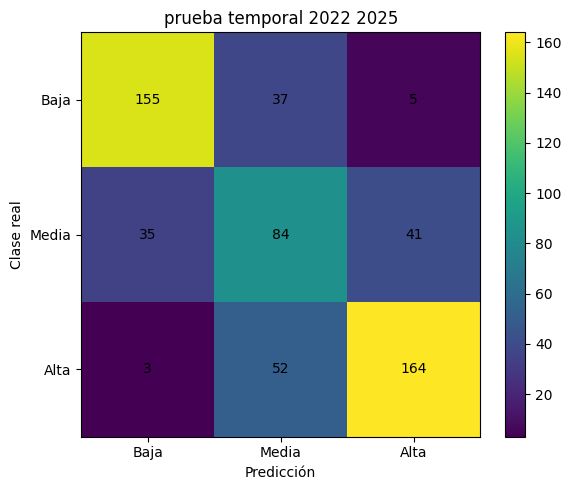

,pred_Baja,pred_Media,pred_Alta
real_Baja,155,37,5
real_Media,35,84,41
real_Alta,3,52,164


In [6]:

save_confusion(
    y_temporal_test,
    pred_temporal,
    "prueba_temporal_2022_2025",
)


In [7]:

temporal_predictions = temporal_test[
    [
        "zone_id",
        "ciudad",
        "region",
        "period_start",
        "target_period_start",
        "target_rx5day_mm",
        "amenaza_mes",
        "target_amenaza",
    ]
].copy()

temporal_predictions["prediccion"] = [
    INT_TO_TARGET[int(value)]
    for value in pred_temporal
]

temporal_predictions["correcta"] = (
    temporal_predictions["target_amenaza"]
    == temporal_predictions["prediccion"]
)

temporal_predictions.to_csv(
    OUTPUT_DIR
    / "predicciones_prueba_temporal_2022_2025.csv",
    index=False,
    encoding="utf-8-sig",
)

temporal_predictions.head()


,zone_id,ciudad,region,period_start,target_period_start,target_rx5day_mm,amenaza_mes,target_amenaza,prediccion,correcta
0,babahoyo,Babahoyo,Litoral,2021-12-01,2022-01-01,202.338418,Media,Alta,Alta,True
1,cuenca,Cuenca,Sierra,2021-12-01,2022-01-01,66.455433,Alta,Media,Media,True
2,esmeraldas,Esmeraldas,Litoral,2021-12-01,2022-01-01,58.384670,Media,Media,Alta,False
3,guayaquil,Guayaquil,Litoral,2021-12-01,2022-01-01,164.516302,Baja,Alta,Alta,True
4,loja,Loja,Sierra,2021-12-01,2022-01-01,78.934366,Media,Alta,Media,False



## Baselines en prueba temporal final

Todos los baselines aprenden sus reglas con el mismo bloque 1991–2021.
\n\nTambién se incluye `Climatologia_zona_mes`, construida únicamente con 1991–2021. Se reporta solo en la prueba temporal de las 12 zonas conocidas; no es válida para zonas espaciales completamente nuevas.

In [8]:

temporal_baselines = baseline_predictions(
    development_through_2021,
    temporal_test,
    include_zone_month=True,
)

temporal_comparison_rows = [
    {
        "modelo": "SVM_RBF",
        **{
            key: temporal_metrics[key]
            for key in [
                "macro_f1",
                "balanced_accuracy",
                "accuracy",
                "recall_alta",
                "f1_baja",
                "f1_media",
                "f1_alta",
            ]
        },
    }
]

for name, pred in temporal_baselines.items():
    row = calculate_metrics(
        y_temporal_test,
        pred,
        f"baseline_{name}",
    )

    temporal_comparison_rows.append({
        "modelo": name,
        **{
            key: row[key]
            for key in [
                "macro_f1",
                "balanced_accuracy",
                "accuracy",
                "recall_alta",
                "f1_baja",
                "f1_media",
                "f1_alta",
            ]
        },
    })

temporal_comparison = (
    pd.DataFrame(temporal_comparison_rows)
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)

temporal_comparison.to_csv(
    OUTPUT_DIR
    / "comparacion_prueba_temporal_baselines.csv",
    index=False,
    encoding="utf-8-sig",
)

temporal_comparison


,modelo,macro_f1,balanced_accuracy,accuracy,recall_alta,f1_baja,f1_media,f1_alta
0,SVM_RBF,0.687982,0.686887,0.699653,0.748858,0.794872,0.504505,0.764569
4,Climatologia_zona_mes,0.673013,0.673315,0.685764,0.707763,0.790123,0.481928,0.746988
2,Persistencia,0.622831,0.622543,0.638889,0.707763,0.744898,0.417445,0.706150
3,Climatologia_mes,0.433966,0.517975,0.560764,0.767123,0.639175,0.000000,0.662722
1,Dummy_most_frequent,0.183648,0.333333,0.380208,1.000000,0.000000,0.000000,0.550943



# PARTE B · Holdout espacial final

Las zonas reservadas son evaluadas sin utilizar sus etiquetas históricas para entrenar el clasificador.

Para conservar causalidad temporal usamos dos modelos congelados:

### Ventana espacial 2018–2021
\[
Train:\ desarrollo\leq2017
\]

### Ventana espacial 2022–2025
\[
Train:\ desarrollo\leq2021
\]

Las predicciones de ambas ventanas se concatenan para obtener una métrica espacio-temporal agregada sobre las 288 filas del holdout.


In [9]:

development_through_2017 = (
    df[
        df["split"]
        == "entrenamiento"
    ]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

spatial_all = (
    df[
        df["split"]
        == "holdout_espacial"
    ]
    .sort_values(
        ["target_period_start", "zone_id"]
    )
    .reset_index(drop=True)
    .copy()
)

spatial_2018_2021 = spatial_all[
    spatial_all["target_period_start"].between(
        "2018-01-01",
        "2021-12-01",
    )
].copy()

spatial_2022_2025 = spatial_all[
    spatial_all["target_period_start"].between(
        "2022-01-01",
        "2025-12-01",
    )
].copy()

if len(spatial_2018_2021) != 144:
    raise ValueError(
        f"Se esperaban 144 filas espaciales 2018-2021, "
        f"se encontraron {len(spatial_2018_2021)}."
    )

if len(spatial_2022_2025) != 144:
    raise ValueError(
        f"Se esperaban 144 filas espaciales 2022-2025, "
        f"se encontraron {len(spatial_2022_2025)}."
    )

print("Zonas holdout:")
print(
    spatial_all[
        ["zone_id", "ciudad"]
    ]
    .drop_duplicates()
    .to_string(index=False)
)


Zonas holdout:
      zone_id        ciudad
        macas         Macas
   nueva_loja    Nueva Loja
santo_domingo Santo Domingo


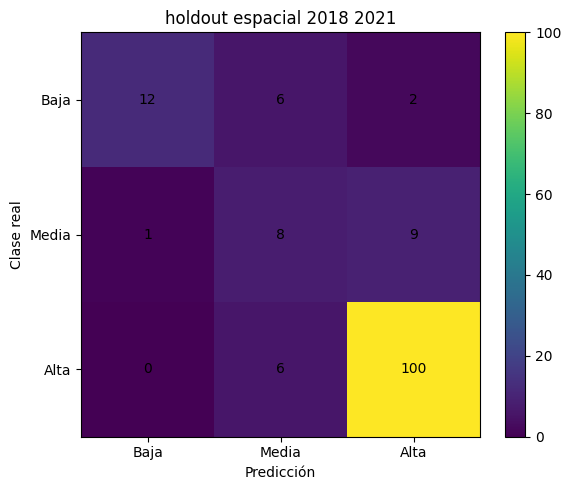

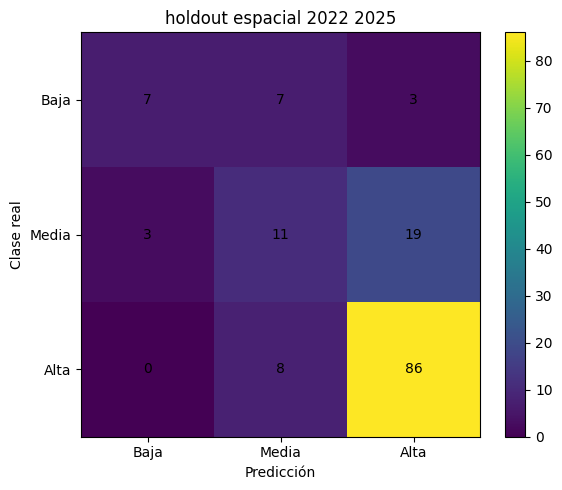

,evaluacion,macro_f1,balanced_accuracy,accuracy,precision_baja,recall_baja,f1_baja,support_baja,precision_media,recall_media,f1_media,support_media,precision_alta,recall_alta,f1_alta,support_alta,n
0,holdout_espacial_2018_2021,0.689995,0.662614,0.833333,0.923077,0.600000,0.727273,20,0.400000,0.444444,0.421053,18,0.900901,0.943396,0.921659,106,144
1,holdout_espacial_2022_2025,0.580962,0.553331,0.722222,0.700000,0.411765,0.518519,17,0.423077,0.333333,0.372881,33,0.796296,0.914894,0.851485,94,144


In [10]:

spatial_specs = [
    {
        "nombre": "holdout_espacial_2018_2021",
        "train": development_through_2017,
        "eval": spatial_2018_2021,
    },
    {
        "nombre": "holdout_espacial_2022_2025",
        "train": development_through_2021,
        "eval": spatial_2022_2025,
    },
]

spatial_metric_rows = []
spatial_prediction_frames = []
spatial_baseline_rows = []

for spec in spatial_specs:
    name = spec["nombre"]
    train_frame = spec["train"]
    eval_frame = spec["eval"]

    X_tr = train_frame[FEATURES]
    y_tr = (
        train_frame["target_amenaza"]
        .map(TARGET_TO_INT)
        .astype(int)
    )

    X_ev = eval_frame[FEATURES]
    y_ev = (
        eval_frame["target_amenaza"]
        .map(TARGET_TO_INT)
        .astype(int)
    )

    model = make_pipeline()
    model.fit(X_tr, y_tr)
    pred = model.predict(X_ev)

    metrics = calculate_metrics(
        y_ev,
        pred,
        name,
    )

    spatial_metric_rows.append(metrics)

    save_confusion(
        y_ev,
        pred,
        name,
    )

    pred_frame = eval_frame[
        [
            "zone_id",
            "ciudad",
            "region",
            "period_start",
            "target_period_start",
            "target_rx5day_mm",
            "amenaza_mes",
            "target_amenaza",
        ]
    ].copy()

    pred_frame["ventana_evaluacion"] = name
    pred_frame["prediccion"] = [
        INT_TO_TARGET[int(value)]
        for value in pred
    ]
    pred_frame["correcta"] = (
        pred_frame["target_amenaza"]
        == pred_frame["prediccion"]
    )

    spatial_prediction_frames.append(
        pred_frame
    )

    baseline_preds = baseline_predictions(
        train_frame,
        eval_frame,
        include_zone_month=False,
    )

    spatial_baseline_rows.append({
        "ventana": name,
        "modelo": "SVM_RBF",
        "macro_f1": metrics["macro_f1"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "accuracy": metrics["accuracy"],
        "recall_alta": metrics["recall_alta"],
        "f1_baja": metrics["f1_baja"],
        "f1_media": metrics["f1_media"],
        "f1_alta": metrics["f1_alta"],
    })

    for baseline_name, baseline_pred in baseline_preds.items():
        bm = calculate_metrics(
            y_ev,
            baseline_pred,
            f"{name}_{baseline_name}",
        )

        spatial_baseline_rows.append({
            "ventana": name,
            "modelo": baseline_name,
            "macro_f1": bm["macro_f1"],
            "balanced_accuracy": bm["balanced_accuracy"],
            "accuracy": bm["accuracy"],
            "recall_alta": bm["recall_alta"],
            "f1_baja": bm["f1_baja"],
            "f1_media": bm["f1_media"],
            "f1_alta": bm["f1_alta"],
        })

spatial_metrics_by_window = pd.DataFrame(
    spatial_metric_rows
)

spatial_metrics_by_window.to_csv(
    OUTPUT_DIR
    / "metricas_holdout_espacial_por_periodo.csv",
    index=False,
    encoding="utf-8-sig",
)

spatial_baseline_comparison = pd.DataFrame(
    spatial_baseline_rows
)

spatial_baseline_comparison.to_csv(
    OUTPUT_DIR
    / "comparacion_holdout_espacial_baselines.csv",
    index=False,
    encoding="utf-8-sig",
)

spatial_metrics_by_window



## Métrica espacial agregada

Las 288 predicciones son todas out-of-sample y espacialmente no vistas. Cada mitad fue generada con un modelo que solo conocía información de desarrollo previa a su ventana.


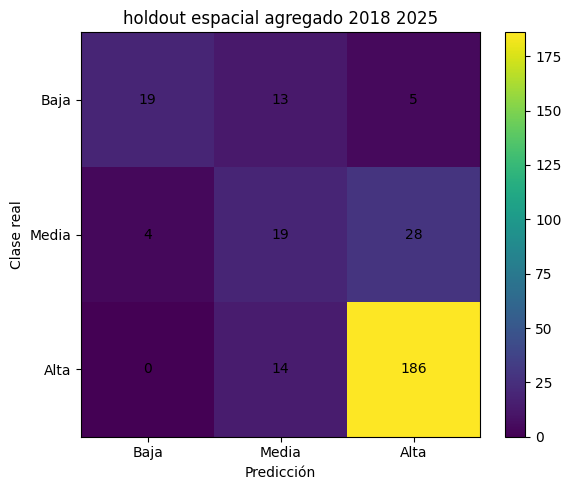

,0
evaluacion,holdout_espacial_agregado_2018_2025
macro_f1,0.637638
balanced_accuracy,0.605354
accuracy,0.777778
precision_baja,0.826087
recall_baja,0.513514
f1_baja,0.633333
support_baja,37
precision_media,0.413043
recall_media,0.372549


In [11]:

spatial_predictions = pd.concat(
    spatial_prediction_frames,
    ignore_index=True,
)

spatial_predictions.to_csv(
    OUTPUT_DIR
    / "predicciones_holdout_espacial.csv",
    index=False,
    encoding="utf-8-sig",
)

y_spatial_true = (
    spatial_predictions["target_amenaza"]
    .map(TARGET_TO_INT)
    .astype(int)
)

y_spatial_pred = (
    spatial_predictions["prediccion"]
    .map(TARGET_TO_INT)
    .astype(int)
)

spatial_aggregate_metrics = calculate_metrics(
    y_spatial_true,
    y_spatial_pred,
    "holdout_espacial_agregado_2018_2025",
)

pd.DataFrame(
    [spatial_aggregate_metrics]
).to_csv(
    OUTPUT_DIR
    / "metricas_holdout_espacial_agregado.csv",
    index=False,
    encoding="utf-8-sig",
)

save_confusion(
    y_spatial_true,
    y_spatial_pred,
    "holdout_espacial_agregado_2018_2025",
)

pd.DataFrame([spatial_aggregate_metrics]).T



## Desempeño por zona del holdout

Este análisis ya es puramente descriptivo: la configuración está congelada y no se cambiará según estas diferencias.


In [12]:

zone_metric_rows = []

for zone_id, zone_frame in spatial_predictions.groupby(
    "zone_id"
):
    y_true_zone = (
        zone_frame["target_amenaza"]
        .map(TARGET_TO_INT)
        .astype(int)
    )

    y_pred_zone = (
        zone_frame["prediccion"]
        .map(TARGET_TO_INT)
        .astype(int)
    )

    metrics = calculate_metrics(
        y_true_zone,
        y_pred_zone,
        f"zona_{zone_id}",
    )

    metrics["zone_id"] = zone_id
    metrics["ciudad"] = zone_frame["ciudad"].iloc[0]
    metrics["region"] = zone_frame["region"].iloc[0]

    zone_metric_rows.append(metrics)

zone_metrics = (
    pd.DataFrame(zone_metric_rows)
    .sort_values(
        "macro_f1",
        ascending=False,
    )
)

zone_metrics.to_csv(
    OUTPUT_DIR
    / "metricas_holdout_espacial_por_zona.csv",
    index=False,
    encoding="utf-8-sig",
)

zone_metrics[
    [
        "zone_id",
        "ciudad",
        "region",
        "macro_f1",
        "balanced_accuracy",
        "recall_alta",
        "f1_baja",
        "f1_media",
        "f1_alta",
        "n",
    ]
]


,zone_id,ciudad,region,macro_f1,balanced_accuracy,recall_alta,f1_baja,f1_media,f1_alta,n
2,santo_domingo,Santo Domingo,Transición Litoral-Sierra,0.618745,0.621220,0.952381,0.655172,0.350000,0.851064,96
0,macas,Macas,Amazonía,0.452381,0.463333,0.840000,0.000000,0.500000,0.857143,96
1,nueva_loja,Nueva Loja,Amazonía,0.362143,0.361111,1.000000,0.000000,0.153846,0.932584,96



# 4. Resumen completo CV → Validación → Evaluación final


In [13]:

summary_rows = []

CV_FILE = STEP06_DIR / "comparacion_modelos_cv.csv"

if CV_FILE.exists():
    cv = pd.read_csv(
        CV_FILE,
        encoding="utf-8-sig",
    )

    svm_cv = cv[
        cv["modelo"] == "SVM_RBF"
    ].iloc[0]

    summary_rows.append({
        "etapa": "CV temporal 1991-2017",
        "macro_f1": float(
            svm_cv["macro_f1_media"]
        ),
        "balanced_accuracy": float(
            svm_cv["balanced_accuracy_media"]
        ),
        "recall_alta": float(
            svm_cv["recall_alta_media"]
        ),
        "n": np.nan,
    })

VALIDATION_FILE = (
    STEP07_DIR
    / "metricas_validacion_svm.csv"
)

if VALIDATION_FILE.exists():
    val = pd.read_csv(
        VALIDATION_FILE,
        encoding="utf-8-sig",
    ).iloc[0]

    summary_rows.append({
        "etapa": "Validación temporal 2018-2021",
        "macro_f1": float(val["macro_f1"]),
        "balanced_accuracy": float(
            val["balanced_accuracy"]
        ),
        "recall_alta": float(
            val["recall_alta"]
        ),
        "n": int(
            val["support_baja"]
            + val["support_media"]
            + val["support_alta"]
        ),
    })

summary_rows.append({
    "etapa": "Prueba temporal final 2022-2025",
    "macro_f1": temporal_metrics["macro_f1"],
    "balanced_accuracy": temporal_metrics[
        "balanced_accuracy"
    ],
    "recall_alta": temporal_metrics["recall_alta"],
    "n": temporal_metrics["n"],
})

summary_rows.append({
    "etapa": "Holdout espacial agregado 2018-2025",
    "macro_f1": spatial_aggregate_metrics["macro_f1"],
    "balanced_accuracy": spatial_aggregate_metrics[
        "balanced_accuracy"
    ],
    "recall_alta": spatial_aggregate_metrics["recall_alta"],
    "n": spatial_aggregate_metrics["n"],
})

final_summary = pd.DataFrame(
    summary_rows
)

final_summary.to_csv(
    OUTPUT_DIR
    / "resumen_evaluacion_final.csv",
    index=False,
    encoding="utf-8-sig",
)

final_summary


,etapa,macro_f1,balanced_accuracy,recall_alta,n
0,CV temporal 1991-2017,0.718816,0.718017,0.713087,NaN
1,Validación temporal 2018-2021,0.689452,0.689196,0.702830,576.0
2,Prueba temporal final 2022-2025,0.687982,0.686887,0.748858,576.0
3,Holdout espacial agregado 2018-2025,0.637638,0.605354,0.930000,288.0


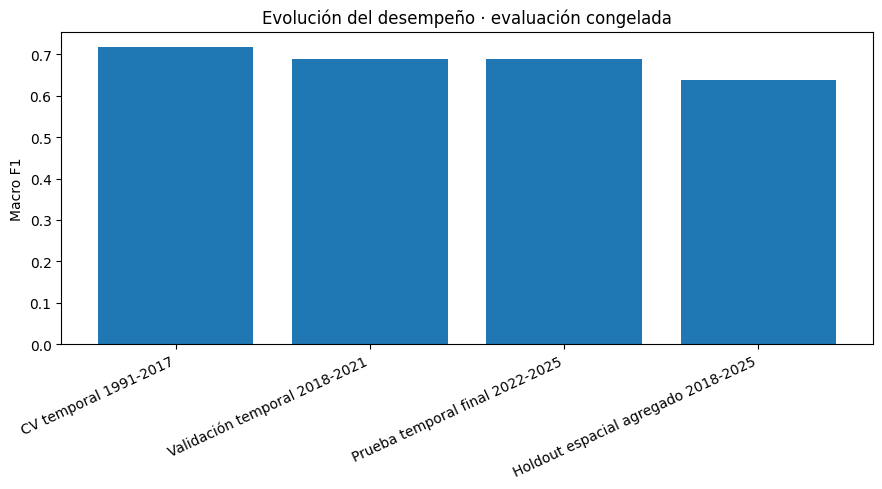

In [14]:

plt.figure(figsize=(9, 5))

plt.bar(
    final_summary["etapa"],
    final_summary["macro_f1"],
)

plt.ylabel("Macro F1")
plt.title("Evolución del desempeño · evaluación congelada")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR
    / "resumen_macro_f1_evaluacion_final.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()



# Fin de la evaluación

Después de ejecutar este notebook:

- `2022–2025` deja de ser un test intacto porque ya habrá sido evaluado.
- las tres zonas espaciales dejan de ser holdout intacto.
- **no se harán cambios retrospectivos al modelo por sus resultados**.

El siguiente Paso 09 será operativo: entrenar el pipeline definitivo para el prototipo y exportarlo, incorporando probabilidades sin reabrir la selección del clasificador.


In [15]:

print("EVALUACIÓN FINAL COMPLETADA")
print("---------------------------")

print(
    f"Prueba temporal 2022–2025 · Macro F1: "
    f"{temporal_metrics['macro_f1']:.4f}"
)
print(
    f"Prueba temporal · Recall Alta: "
    f"{temporal_metrics['recall_alta']:.4f}"
)

print(
    f"\nHoldout espacial agregado · Macro F1: "
    f"{spatial_aggregate_metrics['macro_f1']:.4f}"
)
print(
    f"Holdout espacial agregado · Recall Alta: "
    f"{spatial_aggregate_metrics['recall_alta']:.4f}"
)

print(
    "\nIMPORTANTE: estos conjuntos ya fueron abiertos. "
    "No modificar el modelo en función de estos resultados."
)


EVALUACIÓN FINAL COMPLETADA
---------------------------
Prueba temporal 2022–2025 · Macro F1: 0.6880
Prueba temporal · Recall Alta: 0.7489

Holdout espacial agregado · Macro F1: 0.6376
Holdout espacial agregado · Recall Alta: 0.9300

IMPORTANTE: estos conjuntos ya fueron abiertos. No modificar el modelo en función de estos resultados.
